In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 6.7 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Demo CCTV video created: cctv_sample.mp4
Video: 640x640, 10 FPS, 30 frames
Frame 01: 5 objects -> {'bus': 1, 'person': 4}
Frame 05: 5 objects -> {'bus': 1, 'person': 4}
Frame 10: 5 objects -> {'bus': 1, 'person': 4}
Frame 15: 4 objects -> {'bus': 1, 'person': 3}
Frame 20: 4 objects -> {'bus': 1, 'person': 3}
Frame 25: 4 objects -> {'person': 3, 'bus': 1}
Frame 30: 4 objects -> {'person': 3, 'bus': 1}

Frames processed: 30
Average objects per frame: 4.67
Total detections by class:
  person       109
  bus          30
  stop sign    1
Annotated video saved as: cctv_output.mp4


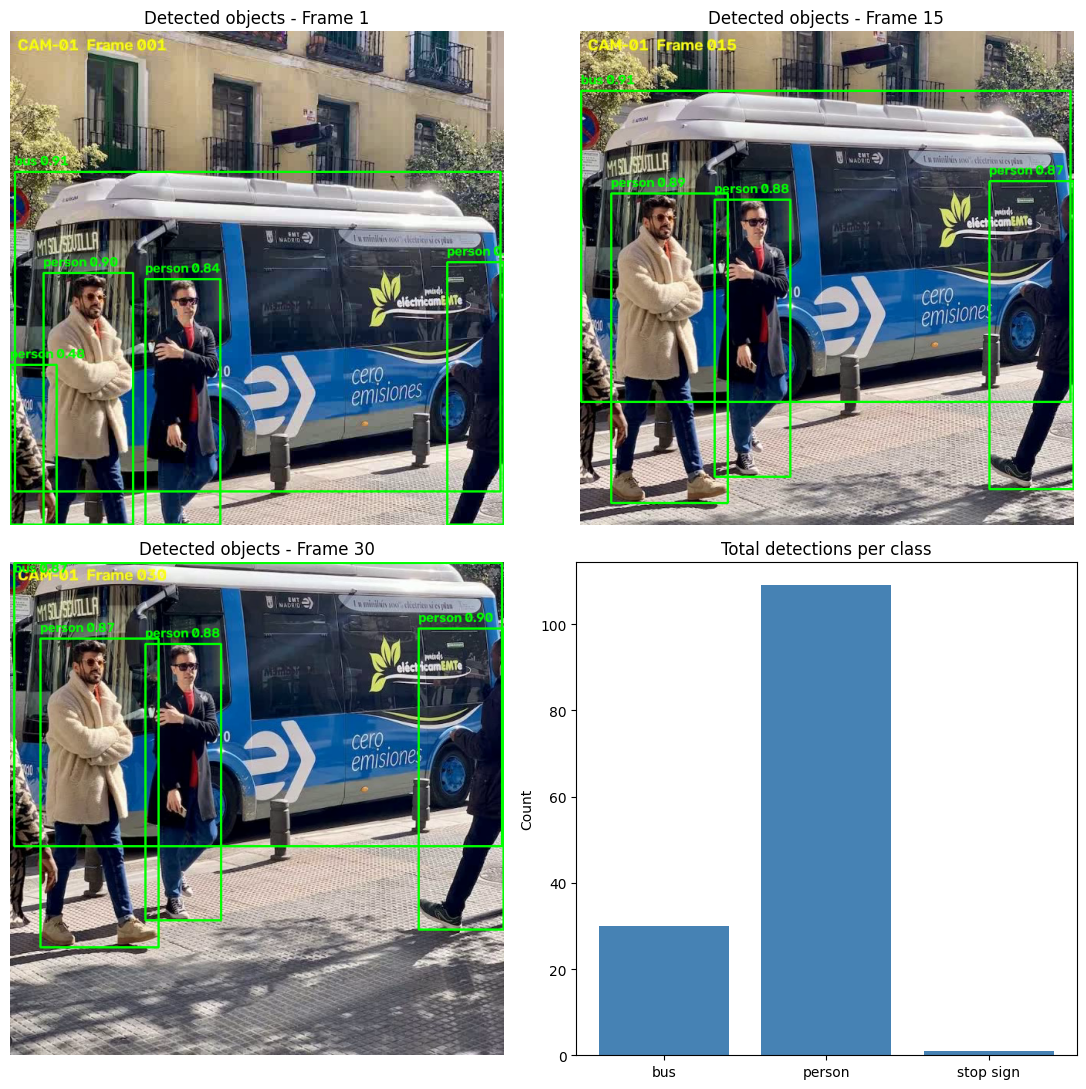

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from ultralytics import YOLO
from ultralytics.utils import ASSETS

VIDEO_PATH = 'cctv_sample.mp4'
OUTPUT_PATH = 'cctv_output.mp4'
CONF_THRESHOLD = 0.40

if not os.path.exists(VIDEO_PATH):
    img = cv2.imread(str(ASSETS / 'bus.jpg'))
    h, w = img.shape[:2]
    out = cv2.VideoWriter(VIDEO_PATH, cv2.VideoWriter_fourcc(*'mp4v'),
                          10, (640, 640))
    for i in range(30):
        top = int(i * (h - w) / 29)
        frame = cv2.resize(img[top:top + w, 0:w], (640, 640))
        cv2.putText(frame, f"CAM-01  Frame {i + 1:03d}", (10, 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
        out.write(frame)
    out.release()
    print("Demo CCTV video created:", VIDEO_PATH)

model = YOLO('yolov8n.pt')

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Video: {width}x{height}, {fps:.0f} FPS, {total} frames")
writer = cv2.VideoWriter(OUTPUT_PATH, cv2.VideoWriter_fourcc(*'mp4v'),
                         fps, (width, height))

total_counts = Counter()
per_frame = []
saved_frames = {}
frame_no = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break
    frame_no += 1
    result = model(frame, conf=CONF_THRESHOLD, verbose=False)[0]
    found = []
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        label = model.names[int(box.cls[0])]
        score = float(box.conf[0])
        found.append(label)
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, f"{label} {score:.2f}", (x1, max(y1 - 8, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    total_counts.update(found)
    per_frame.append(len(found))
    writer.write(frame)
    if frame_no in (1, 15, 30):
        saved_frames[frame_no] = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    if frame_no % 5 == 0 or frame_no == 1:
        print(f"Frame {frame_no:02d}: {len(found)} objects -> "
              f"{dict(Counter(found))}")

cap.release()
writer.release()

print("\nFrames processed:", frame_no)
print("Average objects per frame:", round(float(np.mean(per_frame)), 2))
print("Total detections by class:")
for name, c in total_counts.most_common():
    print(f"  {name:<12} {c}")
print("Annotated video saved as:", OUTPUT_PATH)

fig, ax = plt.subplots(2, 2, figsize=(11, 11))
for a, (n, img) in zip(ax.ravel()[:3], saved_frames.items()):
    a.imshow(img)
    a.set_title(f"Detected objects - Frame {n}")
    a.axis('off')
names = list(total_counts.keys())
ax[1, 1].bar(names, [total_counts[n] for n in names], color='steelblue')
ax[1, 1].set_title("Total detections per class")
ax[1, 1].set_ylabel("Count")
plt.tight_layout()
plt.show()
